# DRT vs Fixed-Route Transit: Multi-Year Panel (2018–2024)
**Transportation Economics Project** | NTD Rural Reporters

**Author:** Sarah Mvuma

### Files needed in the same folder as this notebook:
| Year | Service | Expenses | Fares |
|------|---------|----------|-------|
| 2018 | `2018_Service.xlsx` | `2018_Operating_Expenses.xlsx` | `2018_Fare_Revenue.xlsx` |
| 2019 | `2019_Service.xlsx` | `2019_Operating_Expenses.xlsx` | `2019_Fare_Revenue.xlsx` |
| 2020 | `2020_Service.xlsx` | `2020_Operating_Expenses_0.xlsx` | `2020_Fare_Revenue.xlsx` |
| 2021 | `2021_Service.xlsx` | `2021_Operating_Expenses.xlsx` | `2021_Fare_Revenue.xlsx` |
| 2022 | `2022_Service.xlsx` | `2022_Operating_Expenses.xlsx` | `2022_Fare_Revenue.xlsx` |
| 2023 | `2023_Service.xlsx` | `2023_Operating_Expenses.xlsx` | `2023_Fare_Revenues.xlsx` |
| 2024 | `2024_Service_250812.xlsx` | `2024_Operating_Expenses_250819_0.xlsx` | `2024_Fare_Revenue_250811.xlsx` |

> **Note on 2020–2021:** These COVID years are included in the dataset but flagged with a `COVID` dummy variable. Main regressions exclude them; robustness checks include them with the dummy.

## Step 1: Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## Step 2: Define File Map
Map each year to its three NTD files.

In [6]:
FILE_MAP = {
    2018: {'svc': '2018 Service.xlsx',              'exp': '2018 Operating Expenses.xlsx',        'far': '2018 Fare Revenue.xlsx'},
    2019: {'svc': '2019 Service.xlsx',              'exp': '2019 Operating Expenses.xlsx',        'far': '2019 Fare Revenue.xlsx'},
    2020: {'svc': '2020 Service.xlsx',              'exp': '2020 Operating Expenses_0.xlsx',      'far': '2020 Fare Revenue.xlsx'},
    2021: {'svc': '2021 Service.xlsx',              'exp': '2021 Operating Expenses.xlsx',        'far': '2021 Fare Revenue.xlsx'},
    2022: {'svc': '2022 Service.xlsx',              'exp': '2022 Operating Expenses.xlsx',        'far': '2022 Fare Revenue.xlsx'},
    2023: {'svc': '2023 Service.xlsx',              'exp': '2023 Operating Expenses.xlsx',        'far': '2023 Fare Revenues.xlsx'},
    2024: {'svc': '2024 Service_250812.xlsx',       'exp': '2024 Operating Expenses_250819_0.xlsx','far': '2024 Fare Revenue_250811.xlsx'},
}

print('File map defined for years:', list(FILE_MAP.keys()))

File map defined for years: [2018, 2019, 2020, 2021, 2022, 2023, 2024]


## Step 3: Loader Functions

NTD changed column names slightly across years (e.g., extra spaces in 2023, different VRM/VRH naming in 2019–2020). These functions normalize everything automatically.

In [7]:
def to_numeric(df, cols):
    """Force-convert columns to numeric, coercing non-numeric values to NaN."""
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def load_service(path):
    xl = pd.ExcelFile(path)
    df = pd.read_excel(path, sheet_name=xl.sheet_names[0])
    df.columns = df.columns.str.strip()  # Fix 2023 leading/trailing spaces
    # Normalize VRM: column name varies by year
    vrm = [c for c in df.columns if 'Revenue Miles' in c
           and 'Passenger Car' in c and 'Deadhead' not in c
           and 'Scheduled' not in c and 'Train' not in c]
    vrh = [c for c in df.columns if 'Revenue Hours' in c
           and 'Passenger Car' in c and 'Deadhead' not in c and 'Train' not in c]
    if vrm: df.rename(columns={vrm[0]: 'VRM'}, inplace=True)
    if vrh: df.rename(columns={vrh[0]: 'VRH'}, inplace=True)
    df.rename(columns={'Unlinked Passenger Trips (UPT)': 'UPT',
                       'Passenger Miles': 'PMT'}, inplace=True)
    return to_numeric(df, ['UPT', 'VRH', 'VRM', 'PMT'])


def load_expenses(path):
    xl = pd.ExcelFile(path)
    df = pd.read_excel(path, sheet_name=xl.sheet_names[0])
    df.columns = df.columns.str.strip()
    return to_numeric(df, ['Total Operating Expenses'])


def load_fares(path):
    xl = pd.ExcelFile(path)
    df = pd.read_excel(path, sheet_name=xl.sheet_names[0])
    df.columns = df.columns.str.strip()
    # Column called 'Total Fares' in most years
    fare_col = 'Total Fares' if 'Total Fares' in df.columns \
               else [c for c in df.columns if 'Total' in c and 'Fare' in c][0]
    df.rename(columns={fare_col: 'Fare'}, inplace=True)
    return to_numeric(df, ['Fare'])


print('Loader functions defined.')

Loader functions defined.


## Step 4: Process Each Year

For each year we:
1. Filter to **MB** (fixed-route bus) and **DR** (demand-response) modes
2. Keep **Rural** reporters, **Annual Total** time period, **DO** and **PT** service types
3. Aggregate DO + PT so each row = one agency × one mode
4. Merge service, expenses, and fares
5. Keep only agencies that report **both** MB and DR

In [8]:
def process_year(year, files):
    svc = load_service(files['svc'])
    exp = load_expenses(files['exp'])
    far = load_fares(files['far'])

    # ── Filter ──────────────────────────────────────────
    svc_f = svc[
        (svc['Mode'].isin(['MB', 'DR'])) &
        (svc['Time Period'] == 'Annual Total') &
        (svc['TOS'].isin(['DO', 'PT'])) &
        (svc['Reporting Module'] == 'Rural')
    ].copy()

    exp_f = exp[
        (exp['Mode'].isin(['MB', 'DR'])) &
        (exp['Operating Expense Type'] == 'Total') &
        (exp['TOS'].isin(['DO', 'PT'])) &
        (exp['Reporting Module'] == 'Rural')
    ][['NTD ID', 'Agency Name', 'Mode', 'TOS', 'Total Operating Expenses']].copy()
    exp_f.rename(columns={'Total Operating Expenses': 'OE'}, inplace=True)

    far_f = far[
        (far['Mode'].isin(['MB', 'DR'])) &
        (far['TOS'].isin(['DO', 'PT'])) &
        (far['Reporting Module'] == 'Rural')
    ][['NTD ID', 'Agency Name', 'Mode', 'TOS', 'Fare']].copy()

    # ── Aggregate DO + PT ────────────────────────────────
    num_svc = [c for c in ['UPT', 'VRH', 'VRM', 'PMT'] if c in svc_f.columns]
    svc_agg = svc_f.groupby(['NTD ID', 'Agency Name', 'Mode'])[num_svc].sum(numeric_only=True).reset_index()
    exp_agg = exp_f.groupby(['NTD ID', 'Agency Name', 'Mode'])[['OE']].sum(numeric_only=True).reset_index()
    far_agg = far_f.groupby(['NTD ID', 'Agency Name', 'Mode'])[['Fare']].sum(numeric_only=True).reset_index()

    # ── Merge ────────────────────────────────────────────
    df = svc_agg.merge(exp_agg, on=['NTD ID', 'Agency Name', 'Mode'], how='inner')
    df = df.merge(far_agg,      on=['NTD ID', 'Agency Name', 'Mode'], how='left')
    df['Year'] = year

    # ── Keep agencies with BOTH modes ────────────────────
    agency_modes = df.groupby('Agency Name')['Mode'].apply(set)
    both = agency_modes[agency_modes.apply(lambda x: {'MB', 'DR'}.issubset(x))].index
    return df[df['Agency Name'].isin(both)].copy()


# ── Run all years ────────────────────────────────────────
all_years = []
for year, files in FILE_MAP.items():
    df_year = process_year(year, files)
    print(f'{year}: {len(df_year):>4} rows | {df_year["Agency Name"].nunique():>3} agencies')
    all_years.append(df_year)

2018:  633 rows | 311 agencies
2019:  652 rows | 321 agencies
2020:  624 rows | 308 agencies
2021:  602 rows | 297 agencies
2022:  603 rows | 299 agencies
2023:  584 rows | 284 agencies
2024:  593 rows | 292 agencies


## Step 5: Stack All Years and Compute Economic Variables

| Variable | Formula | What it measures |
|---|---|---|
| `AC` | OE / UPT | Average cost per passenger trip |
| `Cost_per_VRH` | OE / VRH | Supply-side cost per revenue hour |
| `Cost_per_VRM` | OE / VRM | Supply-side cost per revenue mile |
| `Productivity` | UPT / VRH | Trips produced per revenue hour |
| `Subsidy_per_trip` | (OE − Fare) / UPT | Net public subsidy per trip |
| `Farebox_recovery` | Fare / OE | Share of cost recovered from fares |
| `COVID` | 1 if Year ∈ {2020, 2021} | Pandemic indicator for robustness checks |

In [9]:
panel = pd.concat(all_years, ignore_index=True)

# Economic variables
panel['AC']               = panel['OE'] / panel['UPT']
panel['Cost_per_VRH']     = panel['OE'] / panel['VRH']
panel['Cost_per_VRM']     = panel['OE'] / panel['VRM']
panel['Productivity']     = panel['UPT'] / panel['VRH']
panel['Subsidy_per_trip'] = (panel['OE'] - panel['Fare']) / panel['UPT']
panel['Farebox_recovery'] = panel['Fare'] / panel['OE']
panel['COVID']            = panel['Year'].isin([2020, 2021]).astype(int)

# Clean
panel.replace([np.inf, -np.inf], np.nan, inplace=True)
panel = panel[(panel['UPT'] > 0) & panel['AC'].notna()].copy()

print(f'Panel shape:  {panel.shape}')
print(f'Agencies:     {panel["Agency Name"].nunique()}')
print(f'Years:        {sorted(panel["Year"].unique())}')
print(f'\nRows per year:')
print(panel.groupby('Year').size().to_string())

Panel shape:  (4266, 17)
Agencies:     451
Years:        [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Rows per year:
Year
2018    632
2019    652
2020    624
2021    587
2022    599
2023    582
2024    590


## Step 6: Summary Statistics by Mode

In [10]:
metrics = ['AC', 'Cost_per_VRH', 'Cost_per_VRM', 'Productivity', 'Subsidy_per_trip', 'Farebox_recovery']

print(f'{"Metric":<25} {"DR (DRT)":>12} {"MB (Fixed)": >12} {"Ratio DR/MB":>12}')
print('-' * 65)
for m in metrics:
    dr = panel[panel['Mode'] == 'DR'][m].median()
    mb = panel[panel['Mode'] == 'MB'][m].median()
    print(f'{m:<25} {dr:>12.2f} {mb:>12.2f} {dr/mb:>12.2f}x')

Metric                        DR (DRT)   MB (Fixed)  Ratio DR/MB
-----------------------------------------------------------------
AC                               31.04        15.36         2.02x
Cost_per_VRH                     62.82        69.03         0.91x
Cost_per_VRM                      4.49         4.38         1.03x
Productivity                      2.06         4.32         0.48x
Subsidy_per_trip                 28.05        14.37         1.95x
Farebox_recovery                  0.04         0.04         0.98x


In [11]:
# Full descriptive stats
panel.groupby('Mode')[metrics].describe().round(2)

AC                                                  Cost_per_VRH  \
       count   mean     std  min    25%    50%    75%     max        count   
Mode                                                                         
DR    2163.0  38.89   32.53  0.0  19.56  31.04  47.36   569.9       2163.0   
MB    2103.0  27.77  139.82  0.0   8.63  15.36  26.63  6108.0       2103.0   

             ... Subsidy_per_trip          Farebox_recovery                   \
       mean  ...              75%      max            count  mean   std  min   
Mode         ...                                                               
DR    75.22  ...            44.29   561.47           2115.0  0.08  0.15  0.0   
MB    78.93  ...            25.37  6101.50           2055.0  0.06  0.08  0.0   

                              
       25%   50%   75%   max  
Mode                          
DR    0.01  0.04  0.09  1.25  
MB    0.01  0.04  0.08  1.00  

[2 rows x 48 columns]

## Step 7: Trends Over Time (2018–2024)

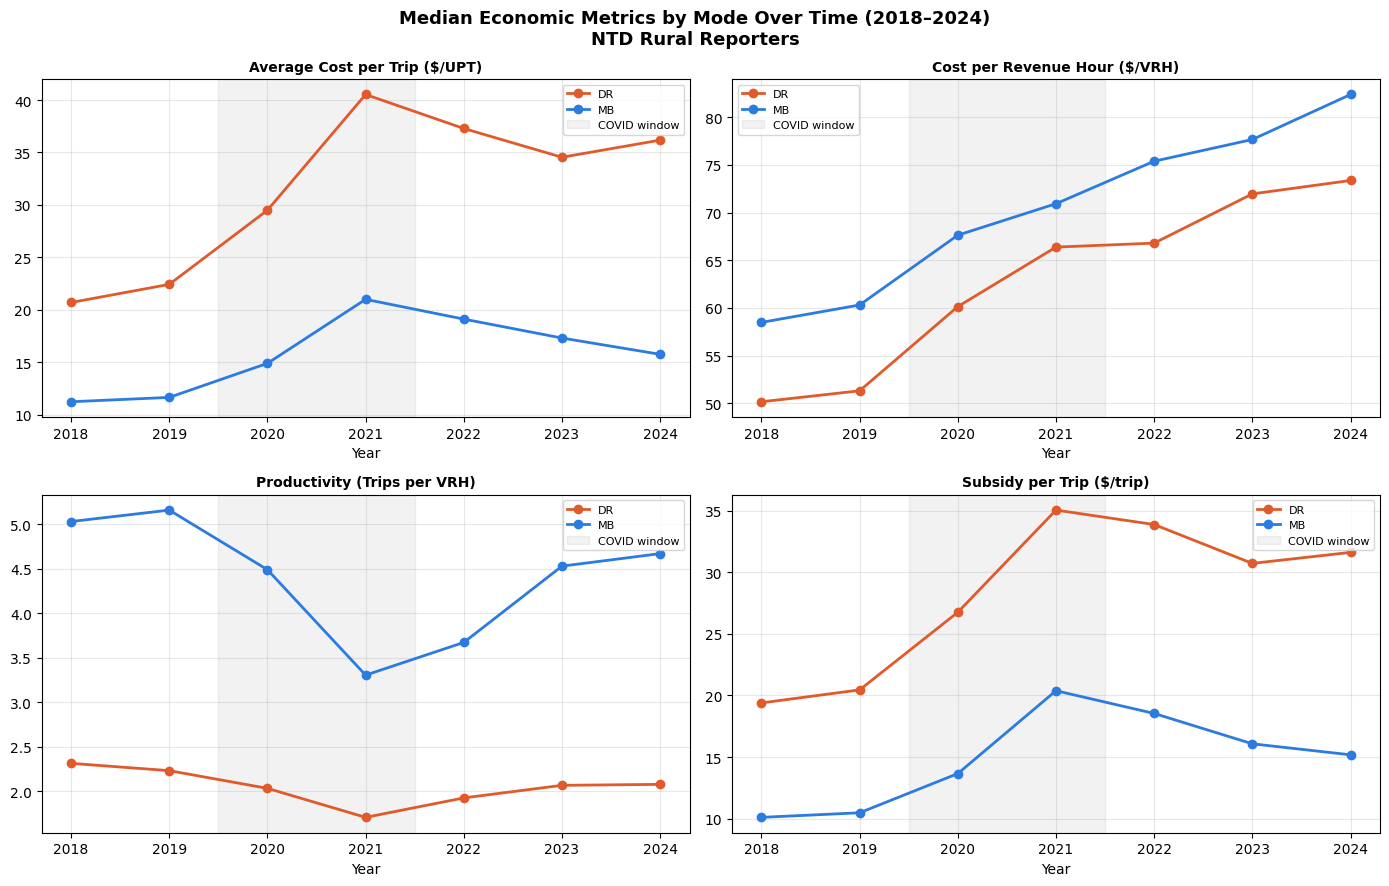

Saved: ntd_trends_2018_2024.png


In [12]:
colors = {'DR': '#E05A2B', 'MB': '#2B7BE0'}
yearly = panel.groupby(['Year', 'Mode'])[['AC', 'Cost_per_VRH', 'Productivity', 'Subsidy_per_trip']].median().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Median Economic Metrics by Mode Over Time (2018–2024)\nNTD Rural Reporters', fontsize=13, fontweight='bold')

plot_vars = [
    ('AC',              'Average Cost per Trip ($/UPT)',      axes[0,0]),
    ('Cost_per_VRH',    'Cost per Revenue Hour ($/VRH)',      axes[0,1]),
    ('Productivity',    'Productivity (Trips per VRH)',        axes[1,0]),
    ('Subsidy_per_trip','Subsidy per Trip ($/trip)',           axes[1,1]),
]

for var, ylabel, ax in plot_vars:
    for mode, color in colors.items():
        sub = yearly[yearly['Mode'] == mode]
        ax.plot(sub['Year'], sub[var], marker='o', color=color, linewidth=2, label=mode)
    ax.axvspan(2019.5, 2021.5, alpha=0.1, color='gray', label='COVID window')
    ax.set_title(ylabel, fontweight='bold', fontsize=10)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ntd_trends_2018_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ntd_trends_2018_2024.png')

## Step 8: Cross-Sectional Exploratory Plots (All Years Pooled)

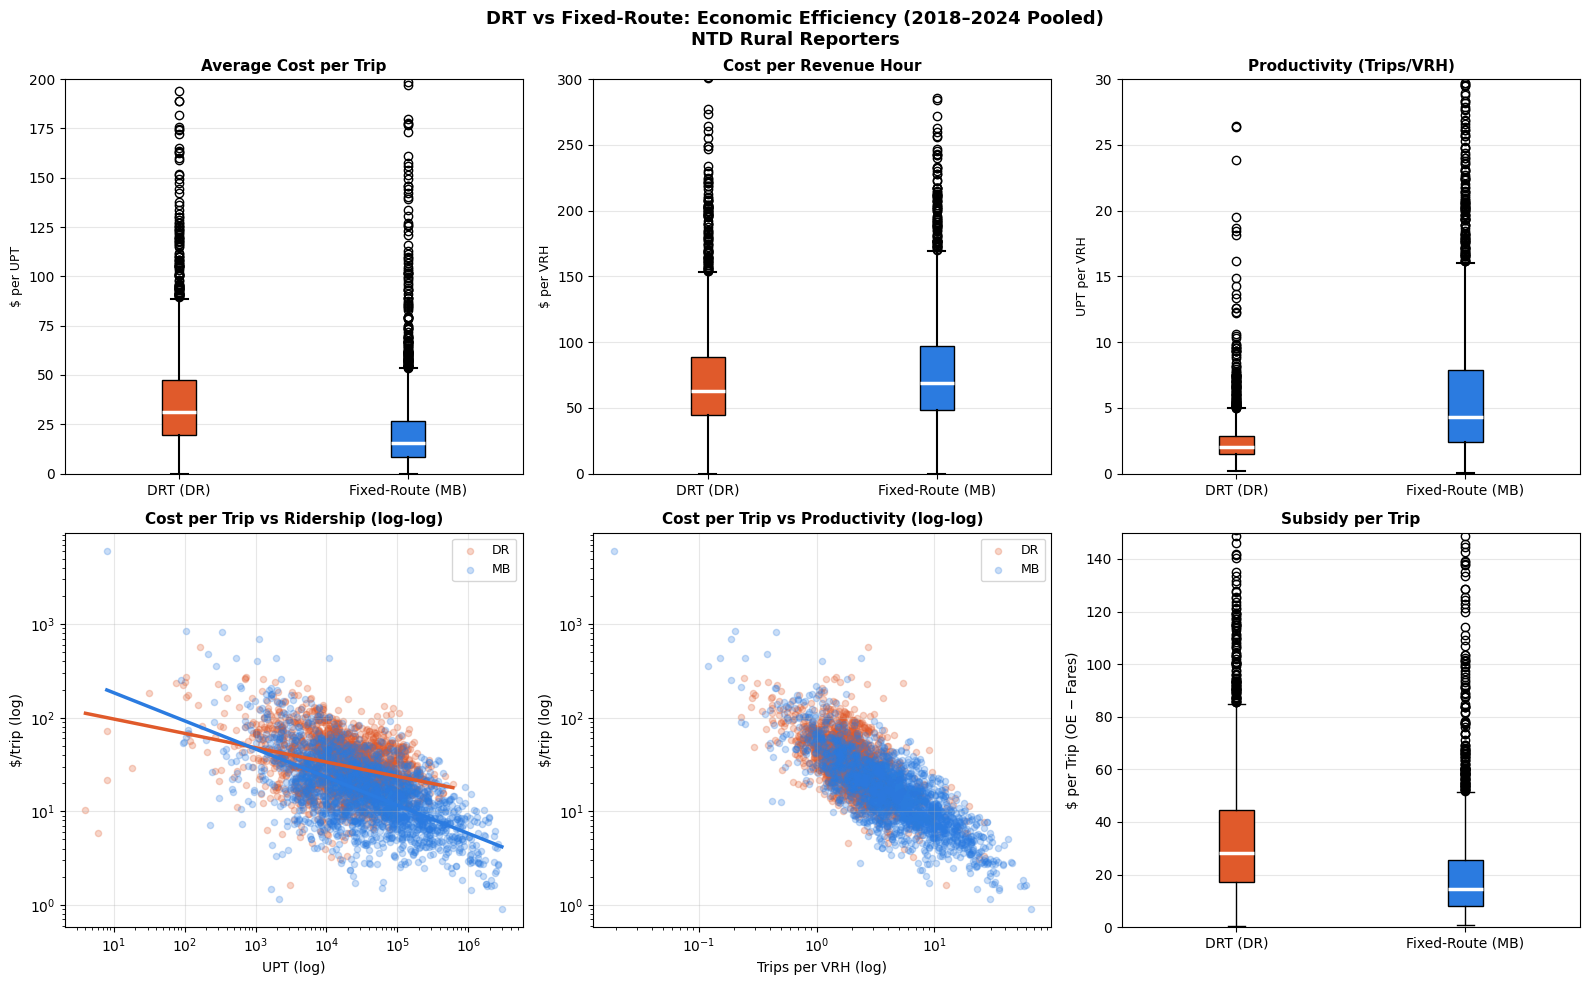

Saved: ntd_exploratory_pooled.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('DRT vs Fixed-Route: Economic Efficiency (2018–2024 Pooled)\nNTD Rural Reporters', fontsize=13, fontweight='bold')

def boxplot_modes(ax, metric, title, ylabel, ylim=None):
    data = [panel[panel['Mode']=='DR'][metric].dropna(),
            panel[panel['Mode']=='MB'][metric].dropna()]
    bp = ax.boxplot(data, tick_labels=['DRT (DR)', 'Fixed-Route (MB)'],
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    bp['boxes'][0].set_facecolor(colors['DR'])
    bp['boxes'][1].set_facecolor(colors['MB'])
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    if ylim: ax.set_ylim(0, ylim)
    ax.grid(axis='y', alpha=0.3)

boxplot_modes(axes[0,0], 'AC',           'Average Cost per Trip',    '$ per UPT',     200)
boxplot_modes(axes[0,1], 'Cost_per_VRH', 'Cost per Revenue Hour',    '$ per VRH',     300)
boxplot_modes(axes[0,2], 'Productivity', 'Productivity (Trips/VRH)', 'UPT per VRH',    30)

# Log-log: AC vs UPT
ax = axes[1,0]
for mode, color in colors.items():
    sub = panel[(panel['Mode']==mode) & (panel['UPT']>0) & (panel['AC']>0)].dropna(subset=['UPT','AC'])
    ax.scatter(sub['UPT'], sub['AC'], alpha=0.25, color=color, s=20, label=mode)
    m_c, b_c = np.polyfit(np.log(sub['UPT']), np.log(sub['AC']), 1)
    xr = np.linspace(sub['UPT'].min(), sub['UPT'].max(), 100)
    ax.plot(xr, np.exp(b_c)*xr**m_c, color=color, linewidth=2.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Cost per Trip vs Ridership (log-log)', fontweight='bold', fontsize=11)
ax.set_xlabel('UPT (log)'); ax.set_ylabel('$/trip (log)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Log-log: AC vs Productivity
ax = axes[1,1]
for mode, color in colors.items():
    sub = panel[(panel['Mode']==mode) & (panel['Productivity']>0) & (panel['AC']>0)].dropna()
    ax.scatter(sub['Productivity'], sub['AC'], alpha=0.25, color=color, s=20, label=mode)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Cost per Trip vs Productivity (log-log)', fontweight='bold', fontsize=11)
ax.set_xlabel('Trips per VRH (log)'); ax.set_ylabel('$/trip (log)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Subsidy
ax = axes[1,2]
data_s = [panel[(panel['Mode']=='DR') & (panel['Subsidy_per_trip']>0)]['Subsidy_per_trip'].dropna(),
          panel[(panel['Mode']=='MB') & (panel['Subsidy_per_trip']>0)]['Subsidy_per_trip'].dropna()]
bp2 = ax.boxplot(data_s, tick_labels=['DRT (DR)', 'Fixed-Route (MB)'],
                 patch_artist=True, medianprops=dict(color='white', linewidth=2.5))
bp2['boxes'][0].set_facecolor(colors['DR'])
bp2['boxes'][1].set_facecolor(colors['MB'])
ax.set_title('Subsidy per Trip', fontweight='bold', fontsize=11)
ax.set_ylabel('$ per Trip (OE − Fares)')
ax.set_ylim(0, 150); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ntd_exploratory_pooled.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ntd_exploratory_pooled.png')

## Step 9: Save Panel Dataset

In [14]:
panel.to_csv('ntd_panel_2018_2024.csv', index=False)
print(f'Saved: ntd_panel_2018_2024.csv')
print(f'Shape: {panel.shape}')
print('\nColumns:', list(panel.columns))
print('\nNext step: regression + break-even threshold analysis.')

Saved: ntd_panel_2018_2024.csv
Shape: (4266, 17)

Columns: ['NTD ID', 'Agency Name', 'Mode', 'UPT', 'VRH', 'VRM', 'PMT', 'OE', 'Fare', 'Year', 'AC', 'Cost_per_VRH', 'Cost_per_VRM', 'Productivity', 'Subsidy_per_trip', 'Farebox_recovery', 'COVID']

Next step: regression + break-even threshold analysis.
